<a href="https://colab.research.google.com/github/bukunmibalogun5-eng/Scikit-Learn/blob/main/SciKit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


In [4]:
from sklearn.datasets import fetch_california_housing

In [6]:
X,y=fetch_california_housing(return_X_y=True)

In [9]:
from sklearn.neighbors import KNeighborsRegressor

In [11]:
mod=KNeighborsRegressor()

In [12]:
mod.fit(X,y)

KNeighborsRegressor()

In [13]:
KNeighborsRegressor()

KNeighborsRegressor()

In [17]:
pred=mod.predict(X)

In [20]:
import matplotlib.pylab as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [22]:
mod=KNeighborsRegressor().fit(X,y)

pipe=Pipeline([
("scale",StandardScaler()),
("model",KNeighborsRegressor())

])

In [23]:
pipe.fit(X,y)

Pipeline(steps=[('scale', StandardScaler()), ('model', KNeighborsRegressor())])

In [24]:
pred=pipe.predict(X)

with scaling

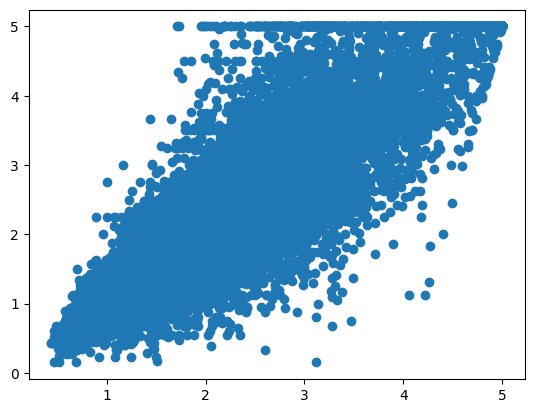

In [25]:
plt.scatter(pred,y)

without scaling

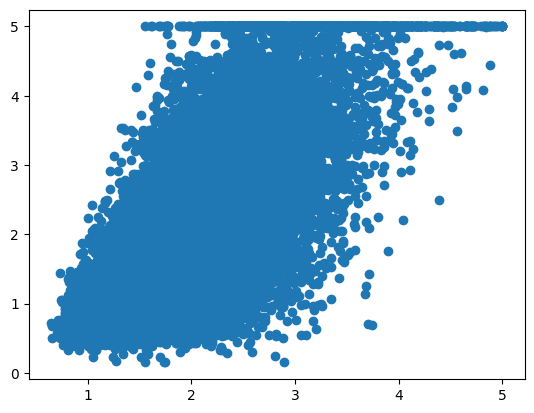

In [19]:
plt.scatter(pred,y)

In [26]:
from sklearn.model_selection import GridSearchCV

In [32]:
mod=GridSearchCV(estimator=pipe,
             param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,20]},
             cv=3)

In [38]:
import pandas as pd

In [39]:
mod.fit(X,y);
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.020866,0.001338,0.394718,0.040171,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.019984,0.000643,0.444474,0.027119,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.019933,0.000542,0.482119,0.046255,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.019623,0.000226,0.500229,0.032920,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.019633,0.000166,0.530426,0.056555,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.030963,0.001512,0.891209,0.035154,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.020242,0.001022,0.557121,0.046249,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.020106,0.001177,0.598644,0.076000,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.020668,0.000969,0.589839,0.034281,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.019819,0.000232,0.711065,0.042497,20,{'model__n_neighbors': 20},0.580342,0.601097,0.533867,0.571768,0.028108,1


###Preprocessing

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

In [43]:
df=pd.read_csv("/content/drawndata1.csv")

In [44]:
df.head(3)

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a


In [45]:
X=df[['x','y']].values
y=df[['z']]=="a"

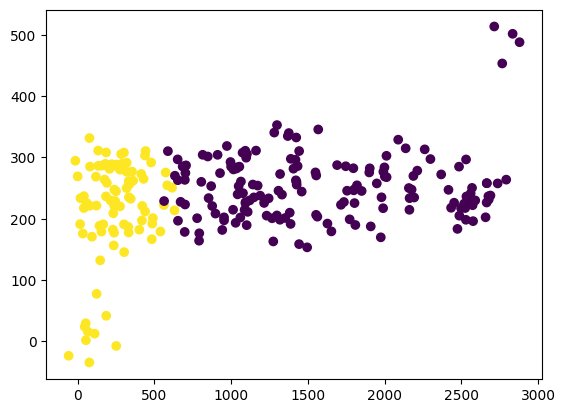

In [55]:
y = y.astype(int)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

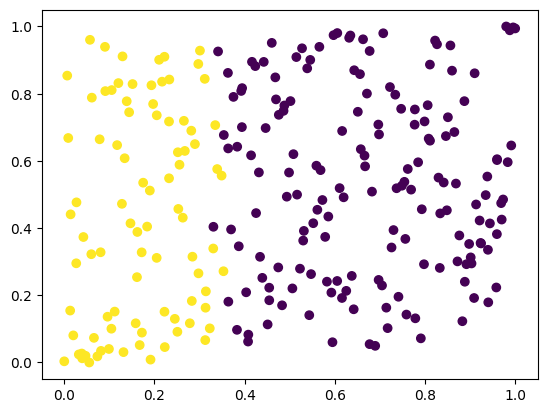

In [56]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c=y);

In [58]:
def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])

    pred = pipe.fit(X, y).predict(X)

    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Original Data")
    plt.subplot(132)
    X_tfm = scaler.transform(X)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=y)
    plt.title("Transformed Data")
    plt.subplot(133)
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)),
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(X_new)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title("Predicted Data")

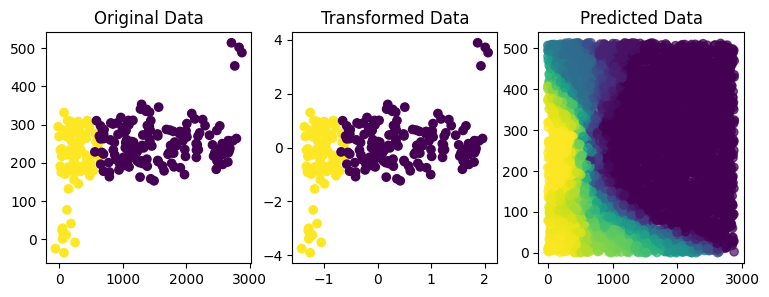

In [59]:
plot_output(scaler=StandardScaler())

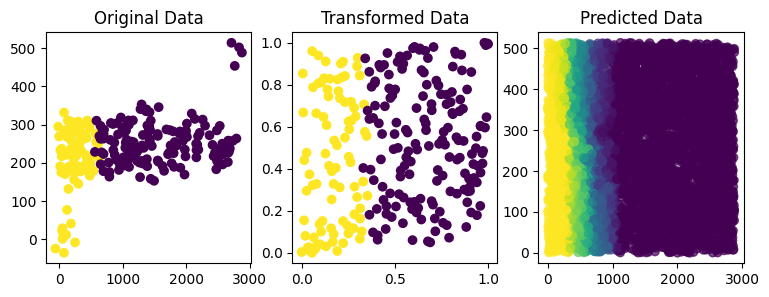

In [61]:
plot_output(scaler=QuantileTransformer(n_quantiles=100))

Using new datset

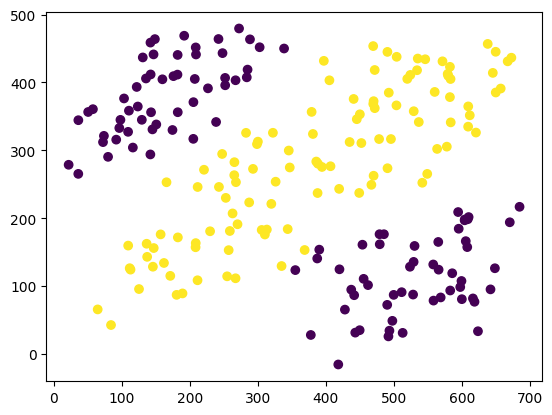

In [62]:
df = pd.read_csv("drawndata2.csv")
X = df[['x', 'y']].values
y = df['z'] == 'a'
plt.scatter(X[:, 0], X[:, 1], c=y);

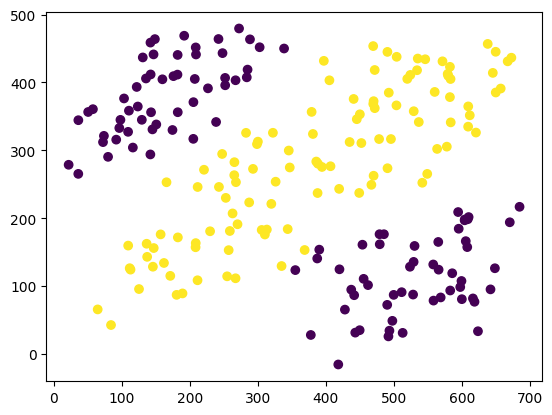

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", PolynomialFeatures()),
    ("model", LogisticRegression())
])

pred = pipe.fit(X, y).predict(X)
plt.scatter(X[:, 0], X[:, 1], c=pred);

One Hot encoding